# Homework 02: Multi-Class Classification with Neural Networks

#### Due Date: Sunday, September 13th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

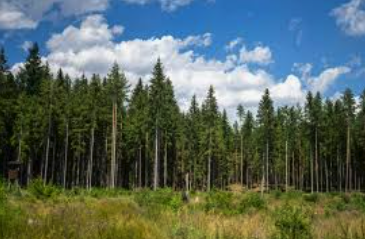

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [3]:
pip install pandas


  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/12/98/e976540c1addf70442be7842a18cf70884a964abbf69442504f4d2939989/pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
  Obtaining dependency information for numpy>=1.26.0 from https://files.pythonhosted.org/packages/3a/5f/62d28cf019460c7f1394105b4d49d9911a9c444cb77ab0bd95a204c5a6de/numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 26.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 17.8 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install matplotlib


  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/c9/cf/b4ad2cc81b6672ea29ea04e64e350a9f9b493b0908ccd884c67eeff8f7b2/matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.5 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/cc/8f/ec6289987824b29529d0dfda0d74a07cec60e54b9c92f3c9da4c0ac732de/contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.28.2 from https://files.pythonhosted.org/packages/dc/8f/e5f2906ea833d362916c64a2f6b1922a07b19442744fd3cd89563f429bff/fonttools-4.64.0-cp312-cp312-manylinux2014_x86

In [7]:
!pip install seaborn scikit-learn tensorflow


  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/6c/c2/63fdda36c56437eeb44aaf9493c8bcd62ce230ab1598924fc626ffbfa943/scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/ce/d7/6e71b4ded8ce99cd21add95611ca14af6e9ad4f2baeabdeb79a4a6b3cb1f/tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/df/64/ff35eb9e54894cf471ff4716abd3c81eb0a0626869217ce3e6ba4ccf17d7/scipy-1.18.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 6.3 MB/s eta 0:

In [8]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

I0000 00:00:1788706164.848668    9280 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788706166.244084    9280 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788706168.881371    9280 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [9]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [10]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [11]:
 # Perform train-test split, keeping both stratified, then standardize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# === Stratified train/test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=random_seed
)

# === Standardize features ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)




### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



In [12]:
# Your code here
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

num_classes = 7  # classes 0–6

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



E0000 00:00:1788706372.289897    9280 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)


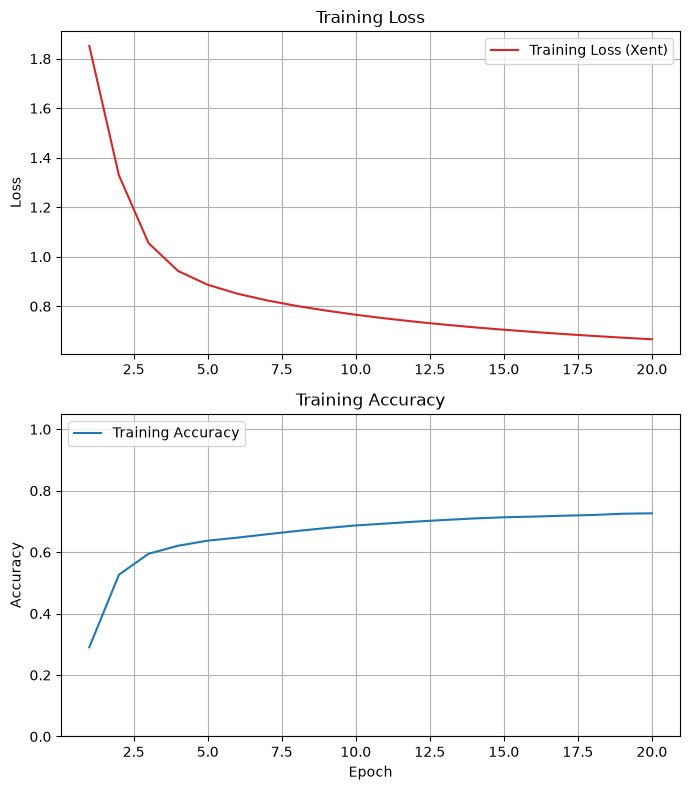

Final Training Loss:     0.6668
Final Training Accuracy: 0.7264


In [15]:
plot_history(history)


In [17]:
# Set a1a to the final training accuracy at epoch 20

a1a = history.history['accuracy'][-1]
print(f'a1a = {a1a:.4f}')
         # Replace 0.0 with your answer

a1a = 0.7264


In [18]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7264


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


=== Training with batch size 4 ===


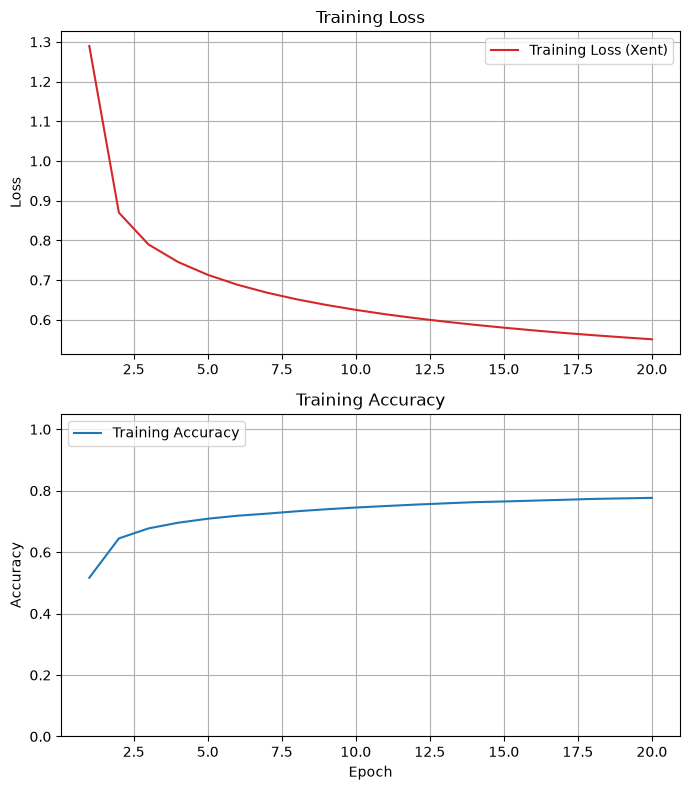

Final Training Loss:     0.5509
Final Training Accuracy: 0.7767
Final training accuracy (bs=4): 0.7767

=== Training with batch size 8 ===


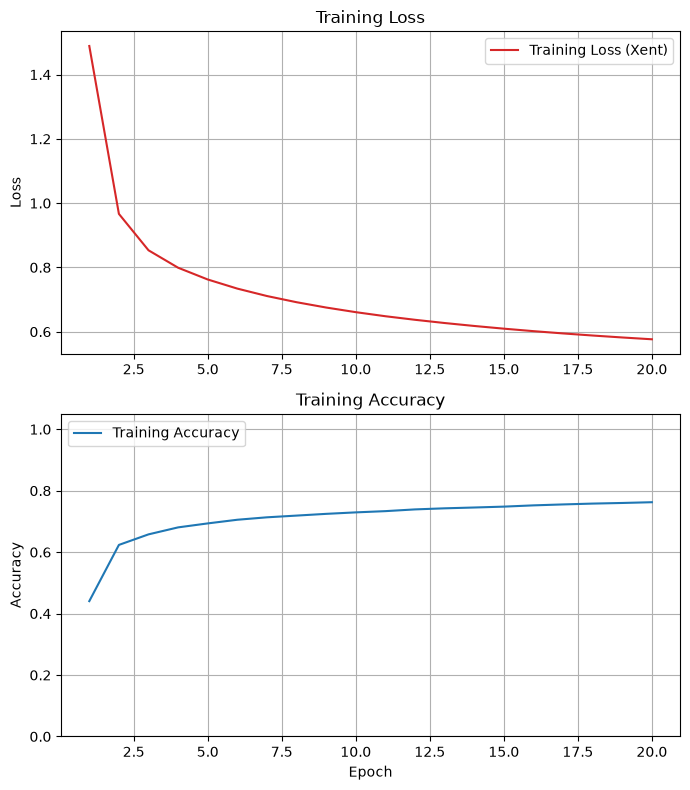

Final Training Loss:     0.5764
Final Training Accuracy: 0.7625
Final training accuracy (bs=8): 0.7625

=== Training with batch size 16 ===


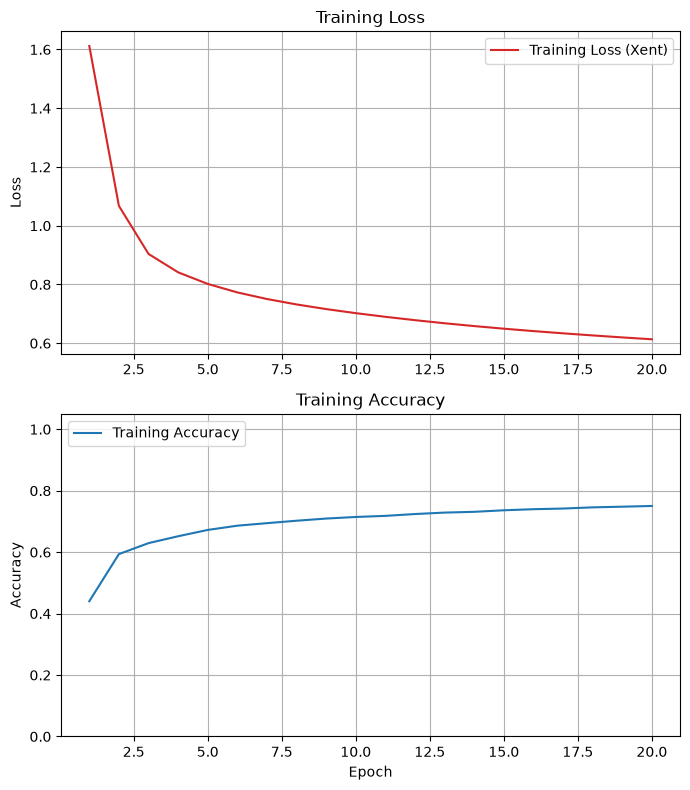

Final Training Loss:     0.6134
Final Training Accuracy: 0.7503
Final training accuracy (bs=16): 0.7503

=== Training with batch size 128 ===


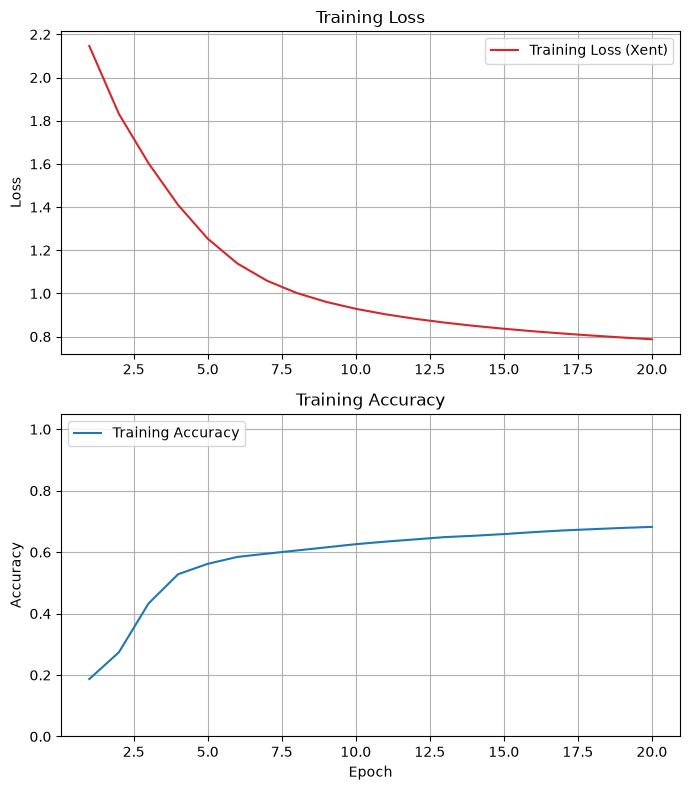

Final Training Loss:     0.7877
Final Training Accuracy: 0.6822
Final training accuracy (bs=128): 0.6822


In [19]:
# Your code here
batch_sizes = [4, 8, 16, 128]
results = {}

for bs in batch_sizes:
    print(f"\n=== Training with batch size {bs} ===")
    
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=bs,
        verbose=0
    )

    plot_history(history)

    final_acc = history.history['accuracy'][-1]
    results[bs] = final_acc
    print(f"Final training accuracy (bs={bs}): {final_acc:.4f}")


In [21]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = 4             # Replace 0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [23]:
# Set a2b to the best accuracy score found

a2b = 0.7767             # Replace 0.0 with your answer

In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7767


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



=== Training with learning rate 0.001 ===


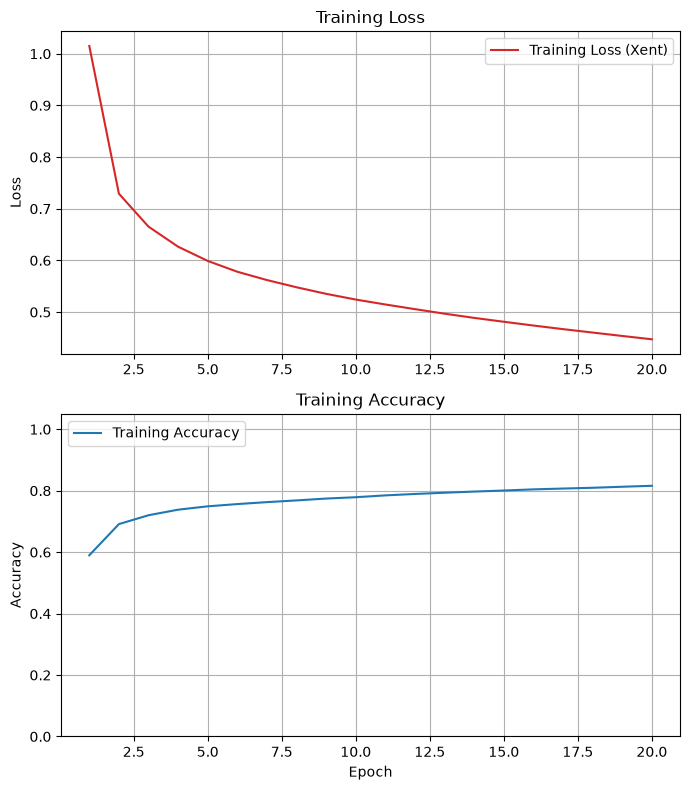

Final Training Loss:     0.4473
Final Training Accuracy: 0.8160
Final training accuracy (lr=0.001): 0.8160

=== Training with learning rate 0.0005 ===


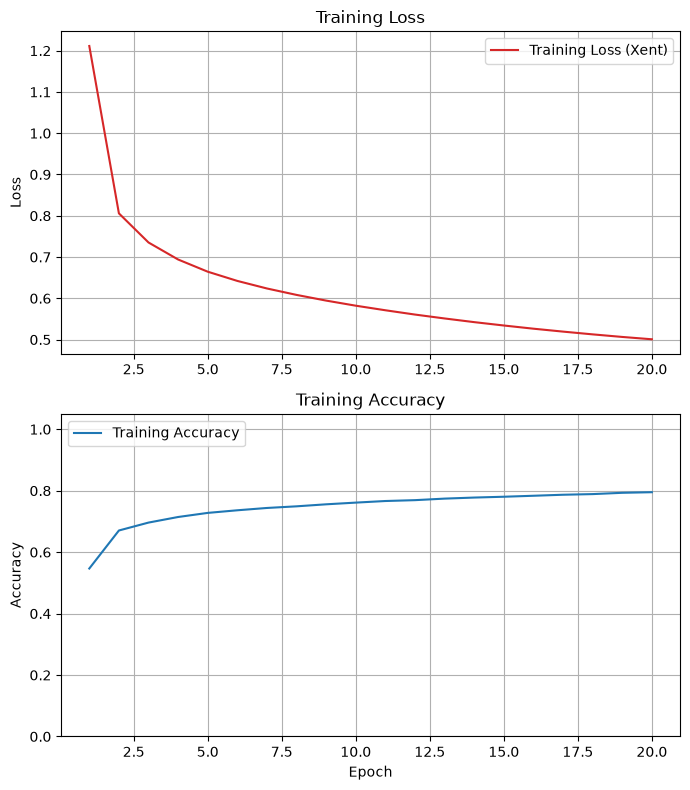

Final Training Loss:     0.5008
Final Training Accuracy: 0.7951
Final training accuracy (lr=0.0005): 0.7951

=== Training with learning rate 0.0001 ===


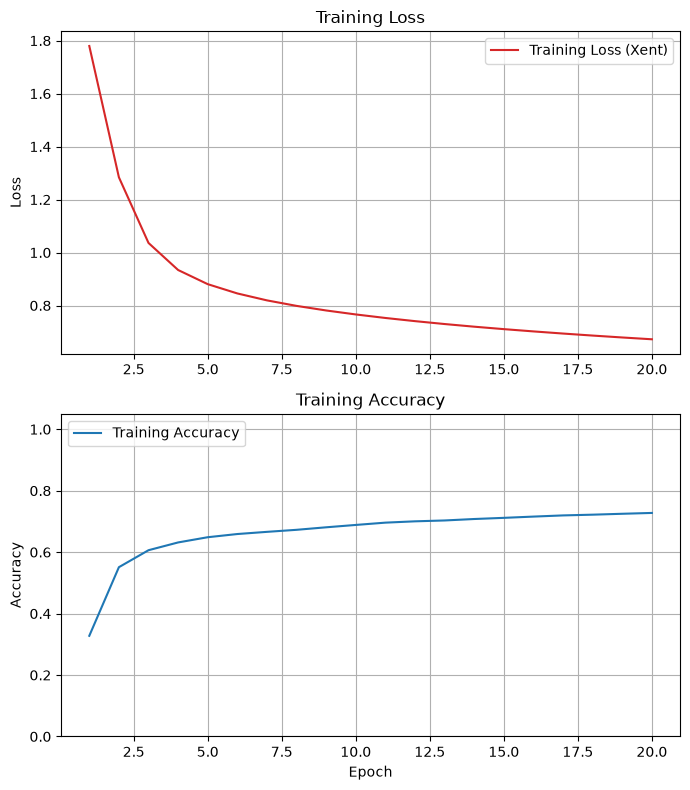

Final Training Loss:     0.6726
Final Training Accuracy: 0.7276
Final training accuracy (lr=0.0001): 0.7276

=== Training with learning rate 5e-05 ===


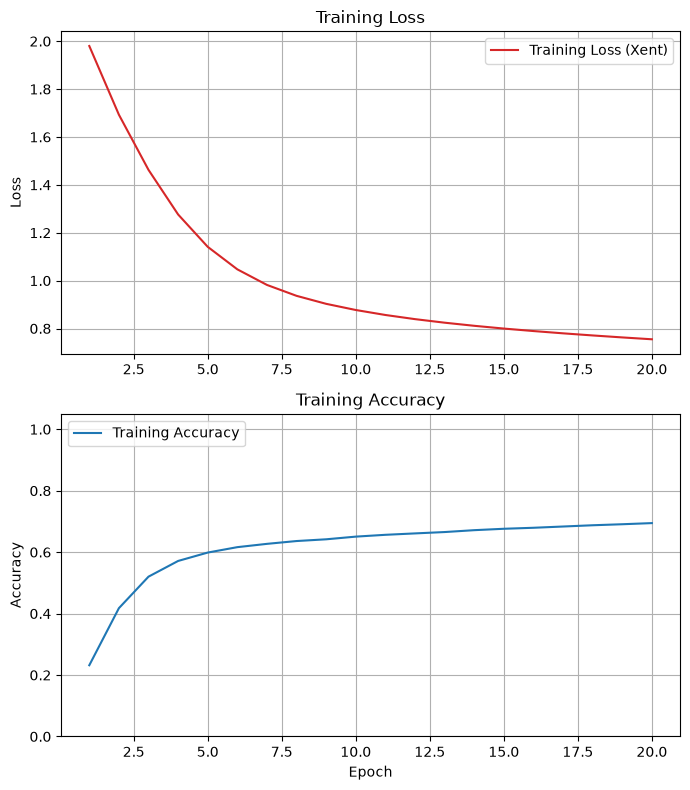

Final Training Loss:     0.7550
Final Training Accuracy: 0.6945
Final training accuracy (lr=5e-05): 0.6945

=== Training with learning rate 1e-05 ===


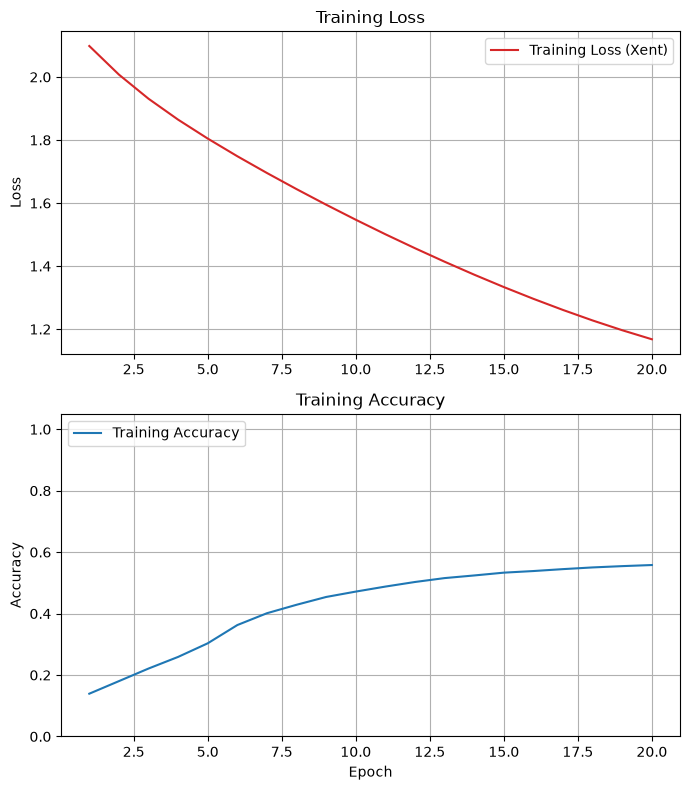

Final Training Loss:     1.1678
Final Training Accuracy: 0.5581
Final training accuracy (lr=1e-05): 0.5581


In [25]:
# Your code here

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
results_lr = {}

for lr in learning_rates:
    print(f"\n=== Training with learning rate {lr} ===")
    
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    plot_history(history)

    final_acc = history.history['accuracy'][-1]
    results_lr[lr] = final_acc
    print(f"Final training accuracy (lr={lr}): {final_acc:.4f}")


In [26]:
results_lr


{0.001: 0.8159656524658203,
 0.0005: 0.7950984835624695,
 0.0001: 0.7276213765144348,
 5e-05: 0.6945329308509827,
 1e-05: 0.5580835938453674}

In [27]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = 0.001            # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [29]:
# Set a3b to the accuracy found by the best learning rate

a3b = 0.81597           # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8160


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.


=== Training with initial LR 0.01 (CosineDecay) ===


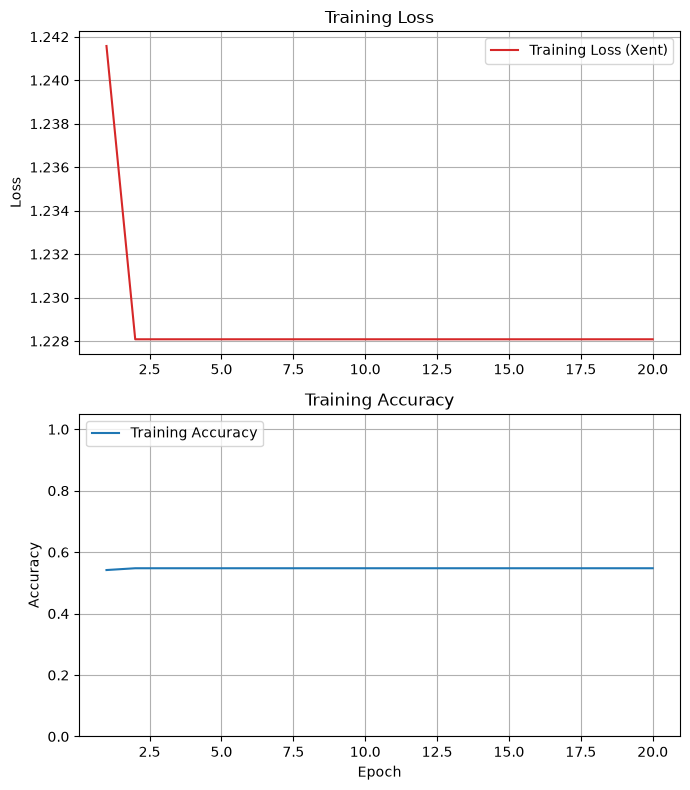

Final Training Loss:     1.2281
Final Training Accuracy: 0.5476
Final training accuracy (initial LR=0.01): 0.5476

=== Training with initial LR 0.005 (CosineDecay) ===


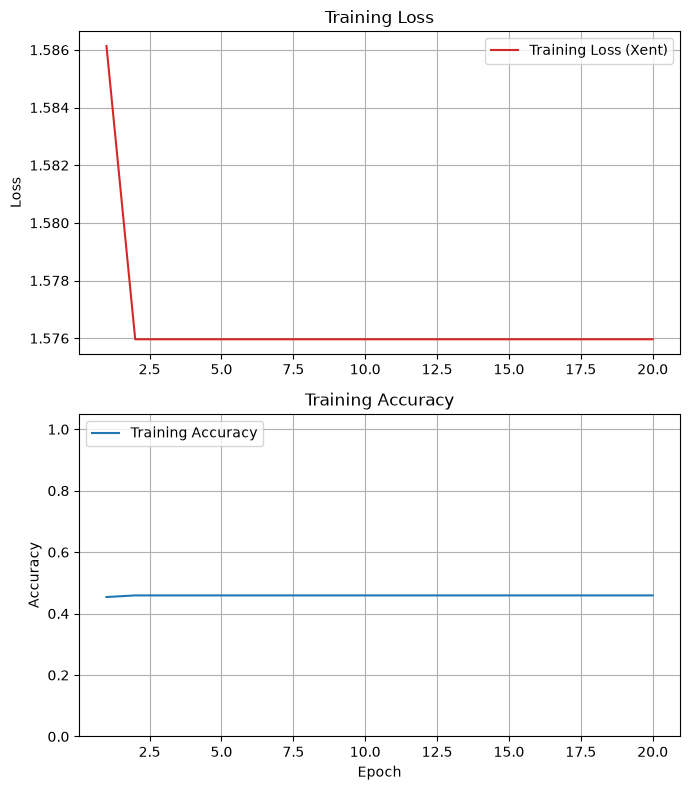

Final Training Loss:     1.5760
Final Training Accuracy: 0.4592
Final training accuracy (initial LR=0.005): 0.4592

=== Training with initial LR 0.001 (CosineDecay) ===


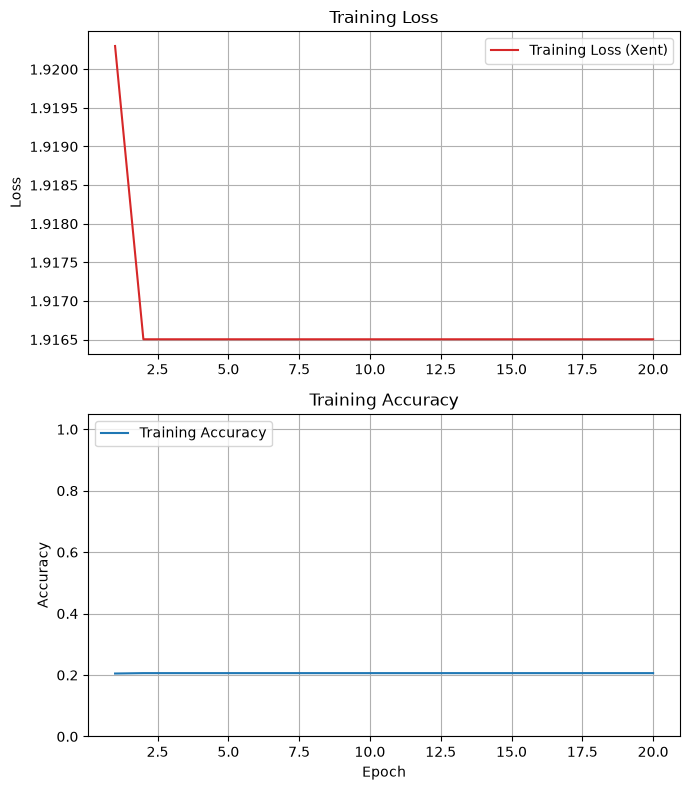

Final Training Loss:     1.9165
Final Training Accuracy: 0.2063
Final training accuracy (initial LR=0.001): 0.2063

=== Training with initial LR 0.0005 (CosineDecay) ===


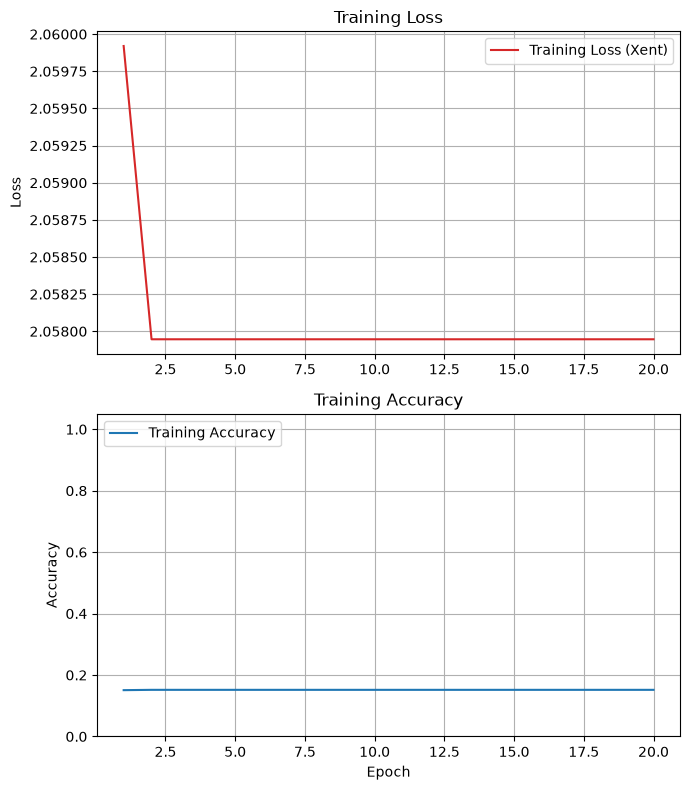

Final Training Loss:     2.0579
Final Training Accuracy: 0.1519
Final training accuracy (initial LR=0.0005): 0.1519

=== Training with initial LR 0.0001 (CosineDecay) ===


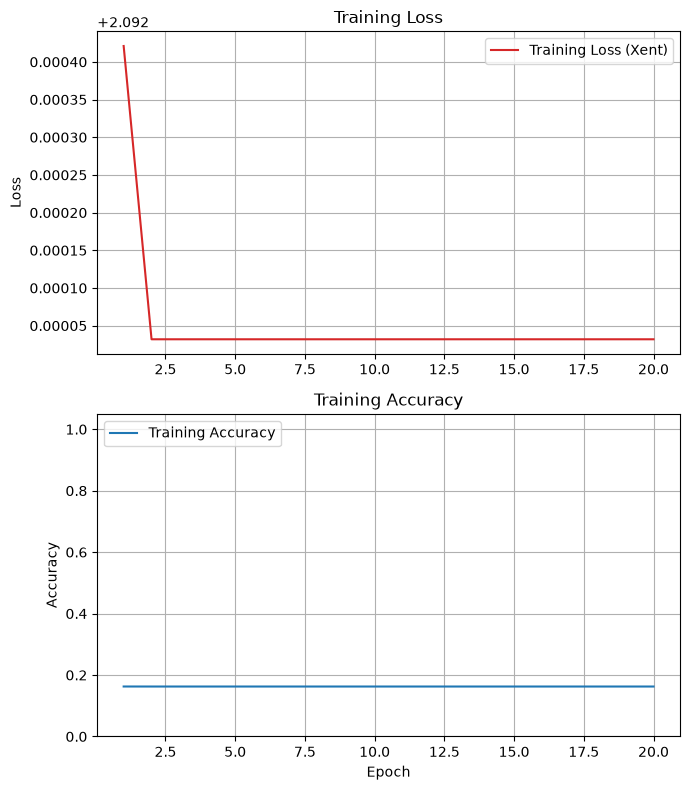

Final Training Loss:     2.0920
Final Training Accuracy: 0.1626
Final training accuracy (initial LR=0.0001): 0.1626


In [31]:
# Your code here

from tensorflow.keras.optimizers.schedules import CosineDecay

initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
results_cd = {}

for lr in initial_lrs:
    print(f"\n=== Training with initial LR {lr} (CosineDecay) ===")

    # Define cosine decay schedule
    lr_schedule = CosineDecay(
        initial_learning_rate=lr,
        decay_steps=20  # one decay step per epoch
    )

    # Build model
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])

    # Compile with Adam using the scheduler
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    # Plot curves
    plot_history(history)

    # Record final training accuracy
    final_acc = history.history['accuracy'][-1]
    results_cd[lr] = final_acc
    print(f"Final training accuracy (initial LR={lr}): {final_acc:.4f}")


In [32]:
results_cd


{0.01: 0.547617495059967,
 0.005: 0.459208220243454,
 0.001: 0.20626665651798248,
 0.0005: 0.1518559455871582,
 0.0001: 0.16264708340168}

In [33]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = 0.01           # Replace 0.0 with your answer

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [35]:
# Set a4b to the best accuracy found

a4b = 0.547617495059967           # Replace 0.0 with your answer

In [36]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.5476


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

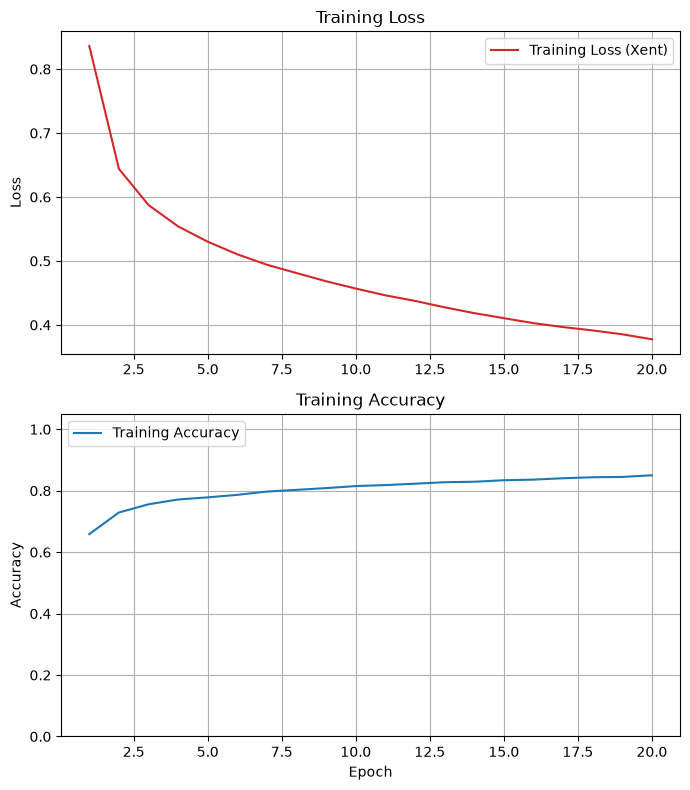

Final Training Loss:     0.3775
Final Training Accuracy: 0.8502
Best training accuracy: 0.8502242565155029
Test accuracy: 0.8185127377510071


In [37]:
# Your code here -- add as many cells as you need
# Build best model
model_best = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

model_best.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train best model
history_best = model_best.fit(
    X_train, y_train,
    epochs=20,
    batch_size=4,
    verbose=0
)

# Plot training curves
plot_history(history_best)

# Extract final training accuracy
best_train_acc = history_best.history['accuracy'][-1]
print("Best training accuracy:", best_train_acc)

# Evaluate on test set
test_loss, test_acc = model_best.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)


In [38]:
# Set a5a to the best training accuracy found by your best model

a5a = 0.8502242565155029           # Replace 0.0 with your answer

In [39]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8502


In [40]:
# Set a5b to the test accuracy found by your best model

a5b = 0.8185127377510071            # Replace 0.0 with your answer

In [41]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8185


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

Increasing the size of the balanced subset would naturally increase training time because each epoch processes more samples, and with more data the optimal batch size often shifts slightly upward since the model benefits less from the noise of tiny batches. The best learning rate may also increase because larger datasets produce smoother gradients that tolerate more aggressive updates. Smaller batches tend to generalize better on tabular data because their noisier gradients help the optimizer explore flatter minima, whereas large batches often require techniques like learning‑rate warmup, higher LR, or added regularization to avoid sharp minima. If we doubled the number of epochs without changing anything else, training loss and accuracy would continue improving while test accuracy would likely peak and then decline due to overfitting. Finally, although it seems intuitive that small learning rates simply require more epochs, our experiments show that learning rate and epoch count are not inversely interchangeable—an unsuitable learning rate can trap the optimizer in poor regions of the loss landscape, and no number of epochs will compensate for that.


# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


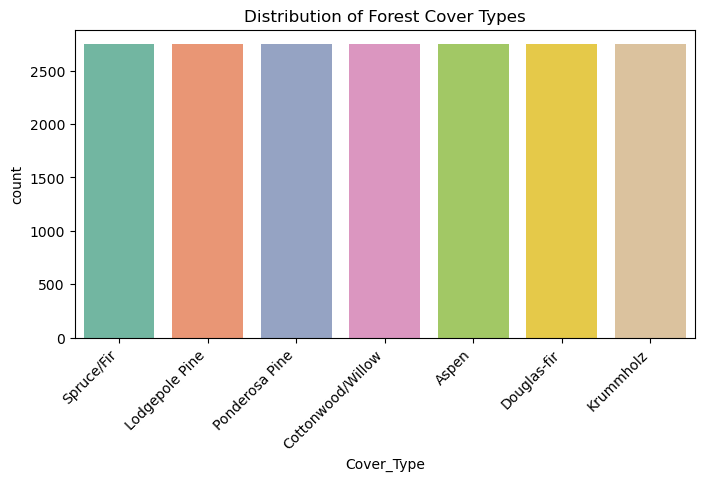

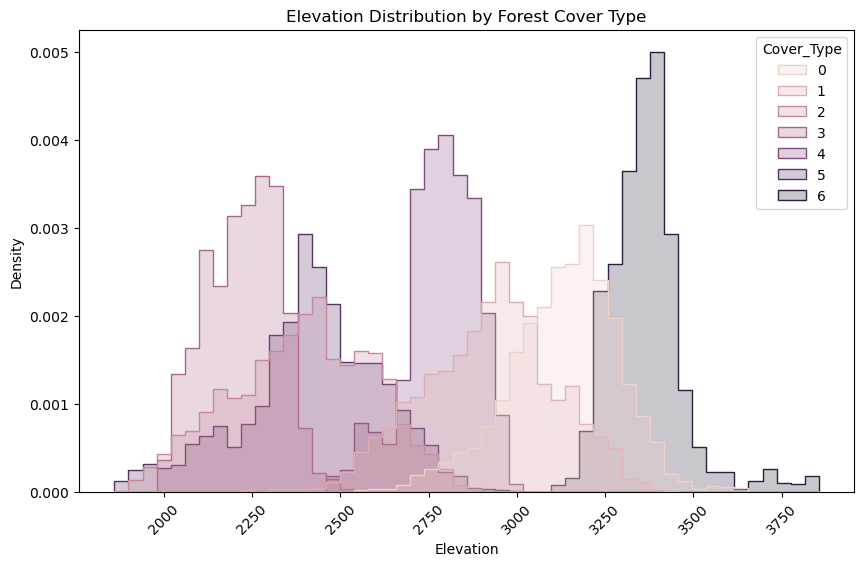

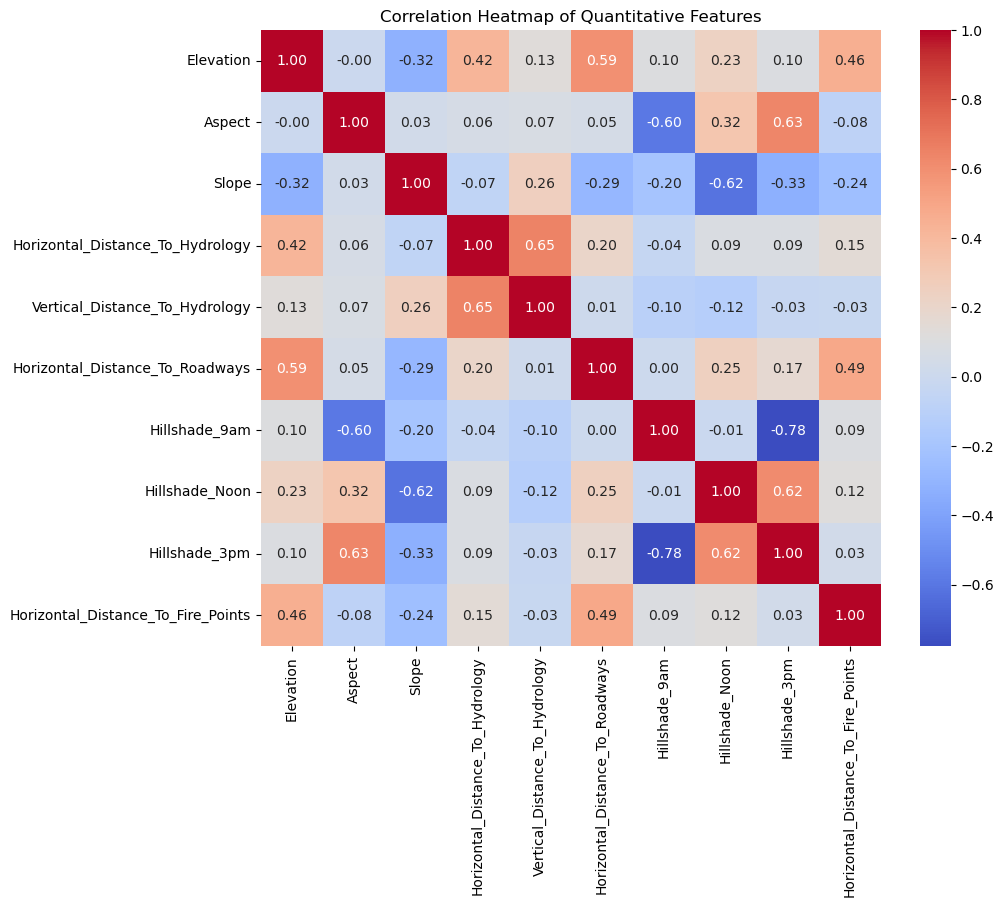

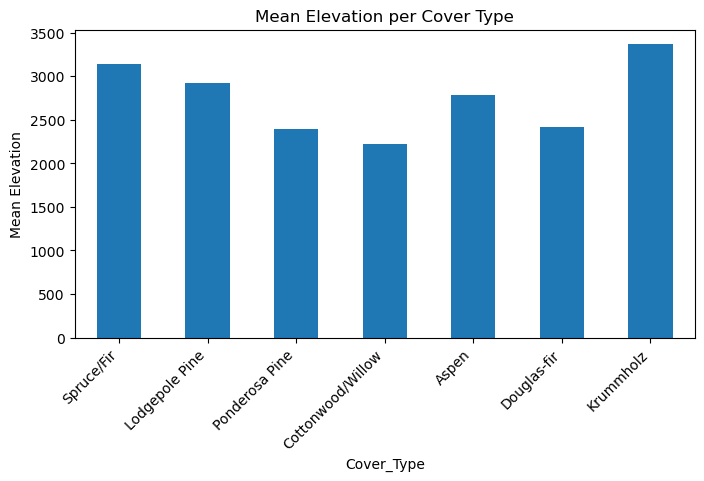

In [28]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()


The Covertype dataset is basically a big collection of 30×30 meter land‑plot measurements paired with the dominant tree type growing there, which makes it a great real‑world example of multi‑class classification on tabular data. It has over half a million samples and a mix of continuous terrain features—like elevation, slope, and distances to hydrology or roads—along with binary wilderness and soil indicators. Because the original dataset is heavily imbalanced, using a balanced subset makes training faster and comparisons fairer. The seven cover types range from common species like Spruce/Fir and Lodgepole Pine to more specific ones like Krummholz, and you can clearly see how certain features, especially elevation, vary across classes. Overall, it’s a useful dataset for practicing preprocessing, scaling, and neural‑network modeling on structured data, and the visualizations help show how terrain and soil characteristics shape forest composition.


